In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [31]:
students_df = pd.read_csv('data/student_lifestyle_dataset.csv')
students_df.head()

,Student_ID,Study_Hours_Per_Day,Extracurricular_Hours_Per_Day,Sleep_Hours_Per_Day,Social_Hours_Per_Day,Physical_Activity_Hours_Per_Day,GPA,Stress_Level
0,1,6.9,3.8,8.7,2.8,1.8,2.99,Moderate
1,2,5.3,3.5,8.0,4.2,3.0,2.75,Low
2,3,5.1,3.9,9.2,1.2,4.6,2.67,Low
3,4,6.5,2.1,7.2,1.7,6.5,2.88,Moderate
4,5,8.1,0.6,6.5,2.2,6.6,3.51,High


In [32]:
students_df.describe()

,Student_ID,Study_Hours_Per_Day,Extracurricular_Hours_Per_Day,Sleep_Hours_Per_Day,Social_Hours_Per_Day,Physical_Activity_Hours_Per_Day,GPA
count,2000.000000,2000.000000,2000.000000,2000.000000,2000.000000,2000.00000,2000.000000
mean,1000.500000,7.475800,1.990100,7.501250,2.704550,4.32830,3.115960
std,577.494589,1.423888,1.155855,1.460949,1.688514,2.51411,0.298674
min,1.000000,5.000000,0.000000,5.000000,0.000000,0.00000,2.240000
25%,500.750000,6.300000,1.000000,6.200000,1.200000,2.40000,2.900000
50%,1000.500000,7.400000,2.000000,7.500000,2.600000,4.10000,3.110000
75%,1500.250000,8.700000,3.000000,8.800000,4.100000,6.10000,3.330000
max,2000.000000,10.000000,4.000000,10.000000,6.000000,13.00000,4.000000


In [33]:
students_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   Student_ID                       2000 non-null   int64  
 1   Study_Hours_Per_Day              2000 non-null   float64
 2   Extracurricular_Hours_Per_Day    2000 non-null   float64
 3   Sleep_Hours_Per_Day              2000 non-null   float64
 4   Social_Hours_Per_Day             2000 non-null   float64
 5   Physical_Activity_Hours_Per_Day  2000 non-null   float64
 6   GPA                              2000 non-null   float64
 7   Stress_Level                     2000 non-null   object 
dtypes: float64(6), int64(1), object(1)
memory usage: 125.1+ KB


(array([ 88.,  87., 104.,  84., 126., 102., 127.,  79., 121.,  99., 110.,
         69., 125.,  75., 117.,  87., 115.,  67., 136.,  82.]),
 array([ 5.  ,  5.25,  5.5 ,  5.75,  6.  ,  6.25,  6.5 ,  6.75,  7.  ,
         7.25,  7.5 ,  7.75,  8.  ,  8.25,  8.5 ,  8.75,  9.  ,  9.25,
         9.5 ,  9.75, 10.  ]),
 <BarContainer object of 20 artists>)

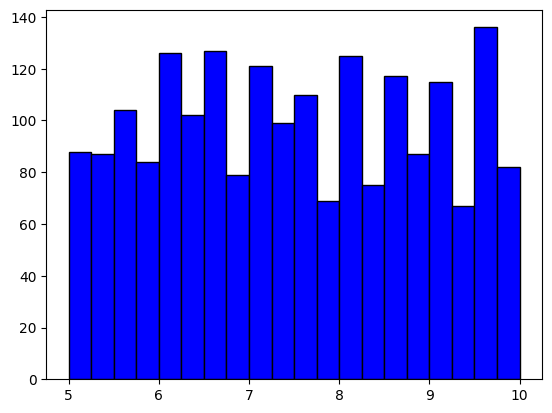

In [34]:
plt.hist(students_df['Study_Hours_Per_Day'], bins=20, color='blue', edgecolor='black')

 This is the strongest story in the notebook. GPA increases clearly as study hours increase, so study time is the best predictor of academic performance here.


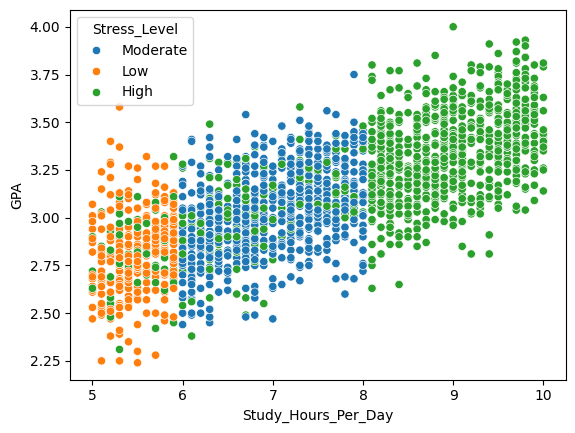

In [35]:
sns.scatterplot(data=students_df,x='Study_Hours_Per_Day', y='GPA',hue='Stress_Level')
print(' This is the strongest story in the notebook. GPA increases clearly as study hours increase, so study time is the best predictor of academic performance here.')

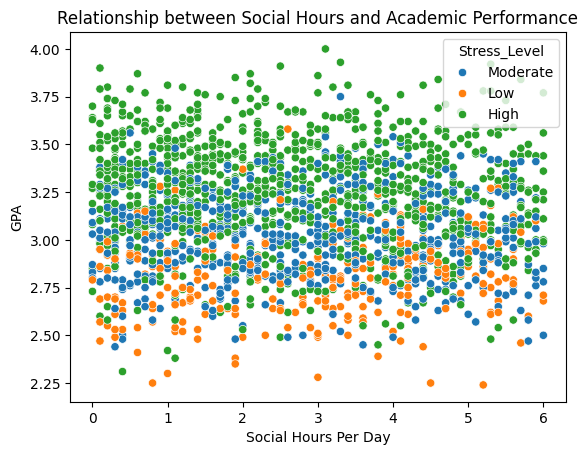

In [36]:
sns.scatterplot(data=students_df,x='Social_Hours_Per_Day', y='GPA',hue='Stress_Level')
plt.xlabel('Social Hours Per Day')
plt.ylabel('GPA')
plt.title('Relationship between Social Hours and Academic Performance')
plt.show()


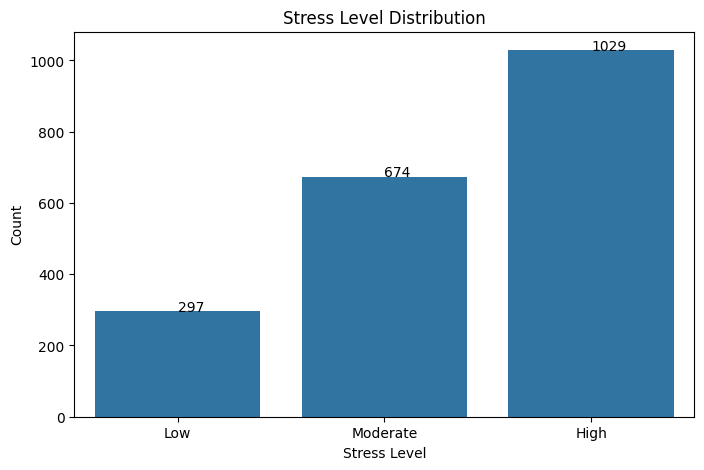

High stress is the largest group, followed by Moderate, then Low. Stress is not rare in this dataset; it is the dominant student condition.


In [52]:
plt.figure(figsize=(8, 5))
ax = sns.countplot(x='Stress_Level', data=students_df,
                   order=['Low', 'Moderate', 'High'])

for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2., p.get_height()))

plt.title('Stress Level Distribution')
plt.xlabel('Stress Level')
plt.ylabel('Count')
plt.show()
print('High stress is the largest group, followed by Moderate, then Low. Stress is not rare in this dataset; it is the dominant student condition.')

Physical activity varies widely. Most students are in a moderate range, but a few have very high activity hours, so this feature has more spread than sleep or study.


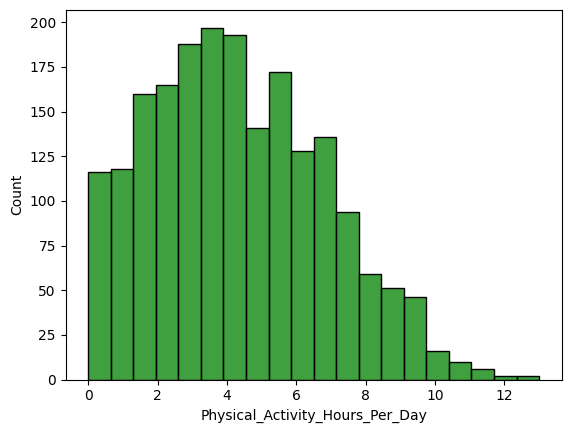

In [38]:
sns.histplot(students_df['Physical_Activity_Hours_Per_Day'], bins=20, color='green', edgecolor='black')
print('Physical activity varies widely. Most students are in a moderate range, but a few have very high activity hours, so this feature has more spread than sleep or study.')

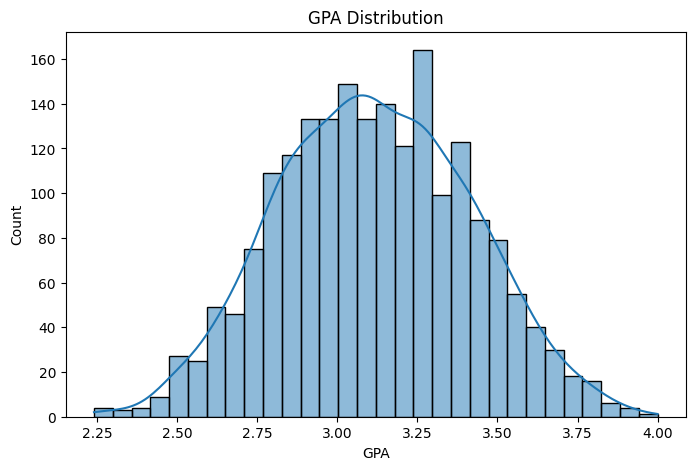

Average GPA: 3.12
Min GPA: 2.24
Max GPA: 4.00
Normal distribution: GPA is centered around 3.1, with most students between about 2.9 and 3.3. Very low and perfect GPAs are less common.


In [56]:
plt.figure(figsize=(8, 5))
sns.histplot(students_df['GPA'], bins=30, kde=True)
plt.title('GPA Distribution')
plt.xlabel('GPA')
plt.ylabel('Count')
plt.show()

print(f"Average GPA: {students_df['GPA'].mean():.2f}")
print(f"Min GPA: {students_df['GPA'].min():.2f}")
print(f"Max GPA: {students_df['GPA'].max():.2f}")
print('Normal distribution: GPA is centered around 3.1, with most students between about 2.9 and 3.3. Very low and perfect GPAs are less common.')

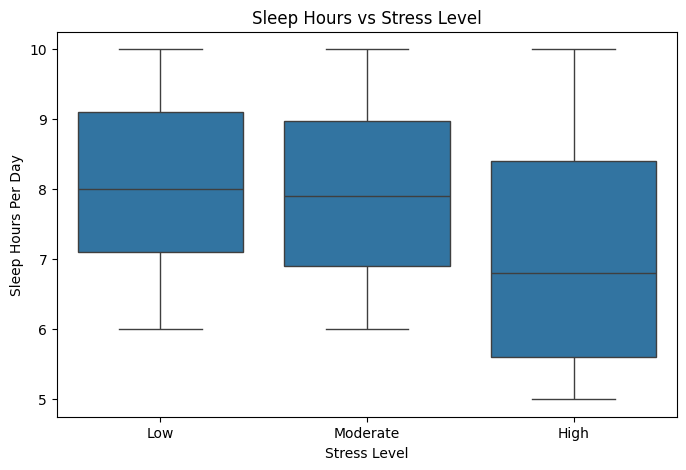

Low-stress students sleep more on average, while high-stress students sleep less. Sleep looks connected to stress more than to GPA.


In [58]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='Stress_Level', y='Sleep_Hours_Per_Day',
            data=students_df,
            order=['Low', 'Moderate', 'High'])
plt.title('Sleep Hours vs Stress Level')
plt.xlabel('Stress Level')
plt.ylabel('Sleep Hours Per Day')
plt.show()
print('Low-stress students sleep more on average, while high-stress students sleep less. Sleep looks connected to stress more than to GPA.')

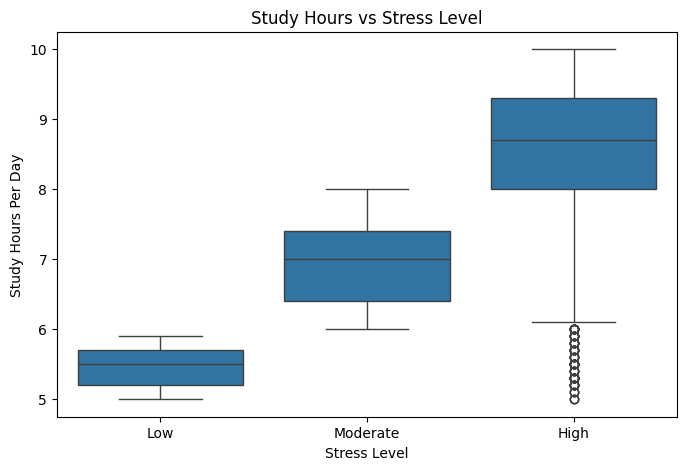

High-stress students study the most, moderate-stress students are in the middle, and low-stress students study the least. This suggests stress may be linked to academic workload.


In [59]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='Stress_Level', y='Study_Hours_Per_Day',
            data=students_df,
            order=['Low', 'Moderate', 'High'])
plt.title('Study Hours vs Stress Level')
plt.xlabel('Stress Level')
plt.ylabel('Study Hours Per Day')
plt.show()
print('High-stress students study the most, moderate-stress students are in the middle, and low-stress students study the least. This suggests stress may be linked to academic workload.')

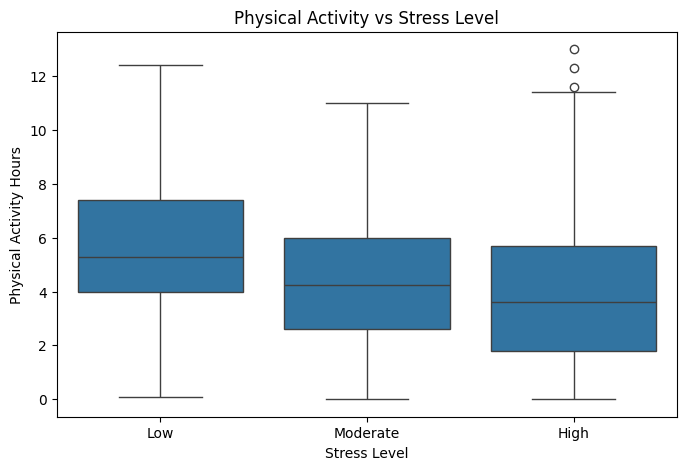

Low-stress students tend to have more physical activity, while high-stress students show less. Activity may be a useful balance factor.


In [60]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='Stress_Level', y='Physical_Activity_Hours_Per_Day',
            data=students_df,
            order=['Low', 'Moderate', 'High'])
plt.title('Physical Activity vs Stress Level')
plt.xlabel('Stress Level')
plt.ylabel('Physical Activity Hours')
plt.show()
print('Low-stress students tend to have more physical activity, while high-stress students show less. Activity may be a useful balance factor.')

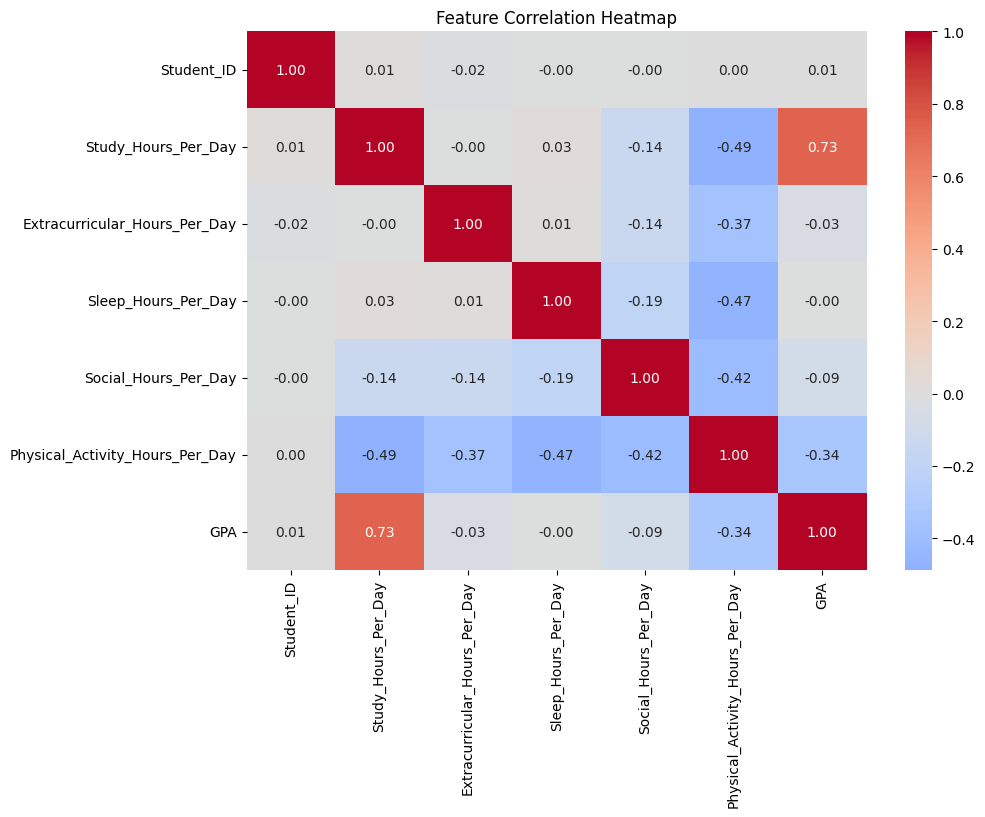

Study_Hours_Per_Day has the strongest positive relationship with GPA. Physical_Activity_Hours_Per_Day has a noticeable negative correlation, likely because students with very high activity may spend less time studying.


In [66]:
plt.figure(figsize=(10, 7))
numeric_students_df = students_df.select_dtypes(include='number')
sns.heatmap(numeric_students_df.corr(),
            annot=True,
            fmt='.2f',
            cmap='coolwarm',
            center=0)
plt.title('Feature Correlation Heatmap')
plt.show()
print('Study_Hours_Per_Day has the strongest positive relationship with GPA. Physical_Activity_Hours_Per_Day has a noticeable negative correlation, likely because students with very high activity may spend less time studying.')

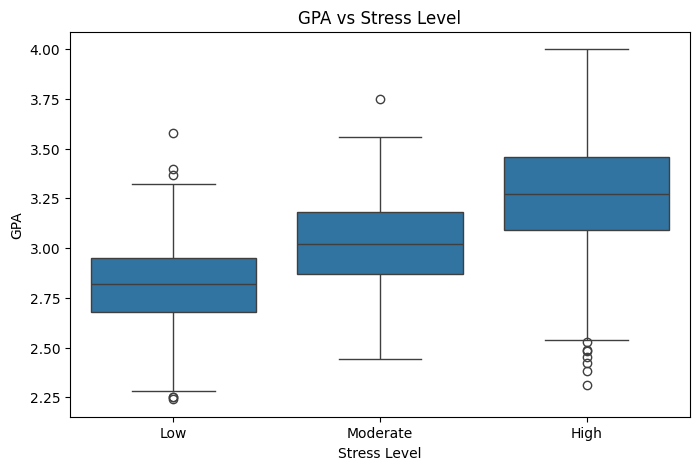

Stress_Level
High        3.261973
Low         2.816869
Moderate    3.024837
Name: GPA, dtype: float64
High-stress students have the highest average GPA, but this does not mean stress is good. It likely reflects that the students pushing hardest academically are also more stressed.


In [68]:
plt.figure(figsize=(8, 5))
sns.boxplot(x='Stress_Level', y='GPA',
            data=students_df,
            order=['Low', 'Moderate', 'High'])
plt.title('GPA vs Stress Level')
plt.xlabel('Stress Level')
plt.ylabel('GPA')
plt.show()

# Average GPA per stress level
print(students_df.groupby('Stress_Level')['GPA'].mean())
print('High-stress students have the highest average GPA, but this does not mean stress is good. It likely reflects that the students pushing hardest academically are also more stressed.')

In [71]:
print('Overall learning: Academic performance in this dataset is mainly a study-hours story, while stress is a workload-and-balance story. The best student profile is not simply high study time; it should also consider sleep and activity because high GPA appears to come with higher stress.')


Overall learning: Academic performance in this dataset is mainly a study-hours story, while stress is a workload-and-balance story. The best student profile is not simply high study time; it should also consider sleep and activity because high GPA appears to come with higher stress.
